In [2]:
import kagglehub
path = kagglehub.dataset_download("s3programmer/flood-risk-in-india")

100%|██████████| 845k/845k [00:00<00:00, 75.2MB/s]

Extracting files...


In [3]:
import os

# List the contents of the downloaded directory
print(f"Contents of the dataset directory: {os.listdir(path)}")

Contents of the dataset directory: ['flood_risk_dataset_india.csv']


In [4]:
import pandas as pd

data_file_path = os.path.join(path, 'flood_risk_dataset_india.csv')
df = pd.read_csv(data_file_path)

print("First 5 rows of the dataset:")
display(df.head())

print("\nInformation about the dataset:")
display(df.info())

First 5 rows of the dataset:


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                10000 non-null  float64
 1   Longitude               10000 non-null  float64
 2   Rainfall (mm)           10000 non-null  float64
 3   Temperature (°C)        10000 non-null  float64
 4   Humidity (%)            10000 non-null  float64
 5   River Discharge (m³/s)  10000 non-null  float64
 6   Water Level (m)         10000 non-null  float64
 7   Elevation (m)           10000 non-null  float64
 8   Land Cover              10000 non-null  object 
 9   Soil Type               10000 non-null  object 
 10  Population Density      10000 non-null  float64
 11  Infrastructure          10000 non-null  int64  
 12  Historical Floods       10000 non-null  int64  
 13  Flood Occurred          10000 non-null  int64  
dtypes: floa

None


Distribution of 'Flood Occurred':


,count
Flood Occurred,
1,5057
0,4943


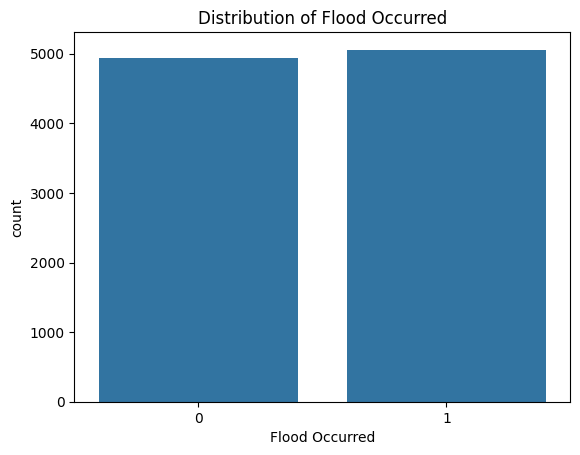


Unique values in 'Land Cover':


,count
Land Cover,
Water Body,2046
Desert,2033
Forest,2005
Agricultural,1978
Urban,1938



Unique values in 'Soil Type':


,count
Soil Type,
Peat,2052
Silt,2044
Clay,1978
Loam,1972
Sandy,1954


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable 'Flood Occurred'
print("\nDistribution of 'Flood Occurred':")
display(df['Flood Occurred'].value_counts())
sns.countplot(x='Flood Occurred', data=df)
plt.title('Distribution of Flood Occurred')
plt.show()

# Unique values in 'Land Cover'
print("\nUnique values in 'Land Cover':")
display(df['Land Cover'].value_counts())

# Unique values in 'Soil Type'
print("\nUnique values in 'Soil Type':")
display(df['Soil Type'].value_counts())

In [6]:
# Perform one-hot encoding on 'Land Cover' and 'Soil Type'
df = pd.get_dummies(df, columns=['Land Cover', 'Soil Type'], drop_first=True)

print("First 5 rows of the DataFrame after one-hot encoding:")
display(df.head())

First 5 rows of the DataFrame after one-hot encoding:


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Population Density,Infrastructure,Historical Floods,Flood Occurred,Land Cover_Desert,Land Cover_Forest,Land Cover_Urban,Land Cover_Water Body,Soil Type_Loam,Soil Type_Peat,Soil Type_Sandy,Soil Type_Silt
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,7276.742184,1,0,1,False,False,False,True,False,False,False,False
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,6897.736956,0,1,0,False,True,False,False,False,True,False,False
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,4361.518494,1,1,1,False,False,False,False,True,False,False,False
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,6163.069701,1,1,0,True,False,False,False,False,False,True,False
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,6167.964591,1,0,0,False,False,False,False,True,False,False,False


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Separate features (X) and target (y)
X = df.drop('Flood Occurred', axis=1)
y = df['Flood Occurred']

# Identify numerical columns for scaling
# Exclude one-hot encoded columns and target from numerical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of scaled X_train:")
display(X_train.head())

Shape of X_train: (8000, 19)
Shape of X_test: (2000, 19)
Shape of y_train: (8000,)
Shape of y_test: (2000,)

First 5 rows of scaled X_train:


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Population Density,Infrastructure,Historical Floods,Land Cover_Desert,Land Cover_Forest,Land Cover_Urban,Land Cover_Water Body,Soil Type_Loam,Soil Type_Peat,Soil Type_Sandy,Soil Type_Silt
452,-0.254624,1.147792,0.528465,-0.731759,-1.301034,-0.565709,0.838999,-0.685853,-1.528308,-0.999000,-1.008284,False,True,False,False,True,False,False,False
8910,0.816961,-0.129773,-0.369140,0.678102,-0.297176,0.094844,0.040386,0.375589,0.294924,1.001001,-1.008284,False,False,False,True,False,True,False,False
4797,0.993910,-1.091381,1.685642,0.003985,0.868581,0.398147,0.483306,0.193563,-0.434901,-0.999000,0.991784,False,False,False,False,False,False,False,True
8111,-0.668580,-1.441856,-0.597537,-0.166119,-1.614433,-1.498599,0.920694,0.179345,-0.616675,-0.999000,-1.008284,False,False,False,True,True,False,False,False
5200,-0.671099,0.463658,-0.012853,1.102162,-0.995405,0.031095,-0.924289,1.356360,1.539888,-0.999000,-1.008284,False,False,False,False,False,False,True,False


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the deep learning model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
print("Model Summary:")
model.summary()

Model Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with Early Stopping
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

print("\nModel training complete.")

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4920 - loss: 0.7201 - val_accuracy: 0.4794 - val_loss: 0.6938
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5039 - loss: 0.6972 - val_accuracy: 0.4794 - val_loss: 0.6941
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4938 - loss: 0.6953 - val_accuracy: 0.4806 - val_loss: 0.6939
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5083 - loss: 0.6935 - val_accuracy: 0.4719 - val_loss: 0.6940
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5009 - loss: 0.6939 - val_accuracy: 0.4800 - val_loss: 0.6942
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4952 - loss: 0.6941 - val_accuracy: 0.4787 - val_loss: 0.6940
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4981 - loss: 0.6933 - val_accuracy: 0.4775 - val_loss: 0.6938
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5044 - loss: 0.6935 - val_accu

In [10]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Predict on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Loss: 0.7259
Test Accuracy: 0.5015
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.65      0.56       989
           1       0.51      0.35      0.42      1011

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.49      2000
weighted avg       0.50      0.50      0.49      2000



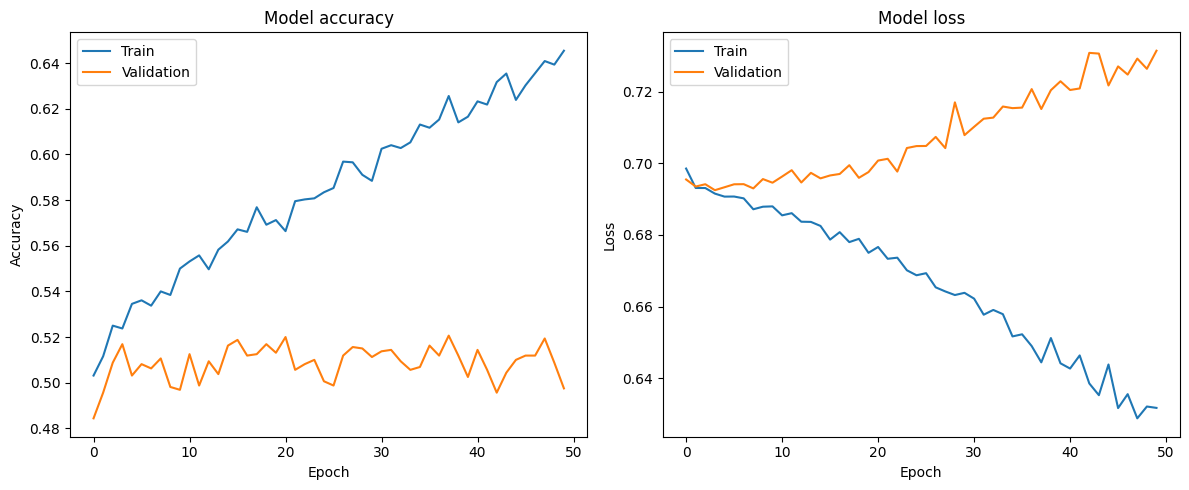

In [11]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [14]:
import pickle
import numpy as np

# Save the trained model
model.save('flood_risk_model.h5')

# Save the StandardScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the list of columns X expects (after one-hot encoding)
model_columns = X.columns.tolist()
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

# Get min/max/mean/std for the original, unscaled numerical features for Streamlit sliders
# We'll use the original 'X' before scaling for these ranges
original_numerical_stats = {
    col: {'min': X[col].min(), 'max': X[col].max(), 'mean': X[col].mean(), 'std': X[col].std()}
    for col in numerical_cols
}

with open('original_numerical_stats.pkl', 'wb') as f:
    pickle.dump(original_numerical_stats, f)

print("Model, scaler, column info, and numerical stats saved successfully!")

Model, scaler, column info, and numerical stats saved successfully!


Now that the model and necessary preprocessing objects are saved, I'll create a Python script for the Streamlit application. This script will include an input panel on the left and use emojis to make it engaging, as you requested. We'll then run this script to launch the app.

In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
import pickle

# Load the trained model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model('flood_risk_model.h5')

model = load_model()

# Load the StandardScaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load the model columns (for consistent input order)
with open('model_columns.pkl', 'rb') as f:
    model_columns = pickle.load(f)

# Load original numerical stats for slider ranges
with open('original_numerical_stats.pkl', 'rb') as f:
    original_numerical_stats = pickle.load(f)

# Define the categorical columns and their unique values (from EDA)
categorical_cols_info = {
    'Land Cover': ['Agricultural', 'Desert', 'Forest', 'Urban', 'Water Body'],
    'Soil Type': ['Alluvial Soil', 'Black Soil', 'Red Soil', 'Laterite Soil', 'Desert Soil']
}

st.set_page_config(page_title="Flood Risk Prediction 🌊", layout="wide")

st.title("🌊 Flood Risk Prediction in India 🇮🇳")
st.write("Enter the environmental and geographical data to predict the likelihood of a flood occurring.")

# Input Panel on the Left (Sidebar)
st.sidebar.header("⚙️ Input Parameters")

# Create input fields for each feature
input_data = {}

# Numerical features
for col in original_numerical_stats:
    stats = original_numerical_stats[col]
    if col in ['Infrastructure', 'Historical Floods']:
        input_data[col] = st.sidebar.number_input(f"**{col}**", min_value=int(stats['min']), max_value=int(stats['max']), value=int(stats['mean']))
    else:
        input_data[col] = st.sidebar.slider(f"**{col}**", float(stats['min']), float(stats['max']), float(stats['mean']))

# Categorical features
for col, unique_values in categorical_cols_info.items():
    input_data[col] = st.sidebar.selectbox(f"**{col}**", unique_values)

# Prediction Button
if st.sidebar.button("Predict Flood Risk 🚨"):
    # Prepare input for the model
    # Convert input_data to a DataFrame
    input_df = pd.DataFrame([input_data])

    # One-hot encode categorical features (consistent with training)
    input_df_encoded = pd.get_dummies(input_df, columns=list(categorical_cols_info.keys()), drop_first=True)

    # Ensure all columns expected by the model are present, fill missing with 0
    # This handles cases where a category might not be present in the single input row
    final_input = pd.DataFrame(0, index=[0], columns=model_columns)
    for col in input_df_encoded.columns:
        if col in final_input.columns:
            final_input[col] = input_df_encoded[col]

    # Scale numerical features (consistent with training)
    final_input[numerical_cols] = scaler.transform(final_input[numerical_cols])

    # Make prediction
    prediction = model.predict(final_input)
    probability_of_flood = prediction[0][0]

    st.subheader("Prediction Result ✨")
    if probability_of_flood >= 0.5:
        st.error(f"\n\n**Flood is LIKELY!** ⚠️ (Probability: {probability_of_flood:.2f})")
        st.balloons()
    else:
        st.success(f"\n\n**Flood is UNLIKELY.** ✅ (Probability: {probability_of_flood:.2f})")

    st.write(f"_Note: A probability of {probability_of_flood:.2f} was calculated._")
    st.info("This prediction is based on the provided input parameters and the trained model. Always refer to official warnings and local authorities for safety.")



Writing app.py


In [23]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
import pickle

# Load the trained model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model('flood_risk_model.h5')

model = load_model()

# Load the StandardScaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load the model columns (for consistent input order)
with open('model_columns.pkl', 'rb') as f:
    model_columns = pickle.load(f)

# Load original numerical stats for slider ranges
with open('original_numerical_stats.pkl', 'rb') as f:
    original_numerical_stats = pickle.load(f)

# Define numerical_cols from the loaded stats (fix for NameError)
numerical_cols = list(original_numerical_stats.keys())

# Define the categorical columns and their unique values (from EDA)
categorical_cols_info = {
    'Land Cover': ['Agricultural', 'Desert', 'Forest', 'Urban', 'Water Body'],
    'Soil Type': ['Alluvial Soil', 'Black Soil', 'Red Soil', 'Laterite Soil', 'Desert Soil']
}

st.set_page_config(page_title="Flood Risk Prediction 🌊", layout="wide")

st.title("🌊 Flood Risk Prediction in India 🇮🇳")
st.write("Enter the environmental and geographical data to predict the likelihood of a flood occurring.")

# Input Panel on the Left (Sidebar)
st.sidebar.header("⚙️ Input Parameters")

# Create input fields for each feature
input_data = {}

# Numerical features
for col in original_numerical_stats:
    stats = original_numerical_stats[col]
    if col in ['Infrastructure', 'Historical Floods']:
        input_data[col] = st.sidebar.number_input(f"**{col}**", min_value=int(stats['min']), max_value=int(stats['max']), value=int(stats['mean']))
    else:
        input_data[col] = st.sidebar.slider(f"**{col}**", float(stats['min']), float(stats['max']), float(stats['mean']))

# Categorical features
for col, unique_values in categorical_cols_info.items():
    input_data[col] = st.sidebar.selectbox(f"**{col}**", unique_values)

# Prediction Button
if st.sidebar.button("Predict Flood Risk 🚨"):
    # Prepare input for the model
    # Convert input_data to a DataFrame
    input_df = pd.DataFrame([input_data])

    # One-hot encode categorical features (consistent with training)
    input_df_encoded = pd.get_dummies(input_df, columns=list(categorical_cols_info.keys()), drop_first=True)

    # Ensure all columns expected by the model are present, fill missing with 0
    # This handles cases where a category might not be present in the single input row
    final_input = pd.DataFrame(0, index=[0], columns=model_columns)
    for col in input_df_encoded.columns:
        if col in final_input.columns:
            final_input[col] = input_df_encoded[col]

    # Scale numerical features (consistent with training)
    final_input[numerical_cols] = scaler.transform(final_input[numerical_cols])

    # Make prediction
    prediction = model.predict(final_input)
    probability_of_flood = prediction[0][0]

    st.subheader("Prediction Result ✨")
    if probability_of_flood >= 0.5:
        st.error(f"\n\n**Flood is LIKELY!** ⚠️ (Probability: {probability_of_flood:.2f})")
        st.balloons()
    else:
        st.success(f"\n\n**Flood is UNLIKELY.** ✅ (Probability: {probability_of_flood:.2f})")

    st.write(f"_Note: A probability of {probability_of_flood:.2f} was calculated._")
    st.info("This prediction is based on the provided input parameters and the trained model. Always refer to official warnings and local authorities for safety.")



Overwriting app.py


In [24]:
!streamlit run app.py &>/dev/null&

The Streamlit app is now running in the background with the fix! 🎉

To view the app, click on the **"Running on local URL: http://localhost:8501"** link that appears in the output of the cell above. If you don't see the link, please run the cell again. You may need to wait a few seconds for the app to start.

You can also find the external URL under **Port 8501** in the **Port Forwarding** section (usually under the `^` icon in the bottom right of the Colab window, or by clicking `Tools > Settings > Other > Port Forwarding`).

Interact with the input parameters in the sidebar to get real-time flood risk predictions!

In [16]:
!streamlit run app.py &>/dev/null&

The Streamlit app is now running in the background! 🎉

To view the app, click on the **"Running on local URL: http://localhost:8501"** link that appears in the output of the cell above. If you don't see the link, please run the cell again. You may need to wait a few seconds for the app to start.

You can also find the external URL under **Port 8501** in the **Port Forwarding** section (usually under the `^` icon in the bottom right of the Colab window, or by clicking `Tools > Settings > Other > Port Forwarding`).

Interact with the input parameters in the sidebar to get real-time flood risk predictions!

In [17]:
!pip install --ignore-installed blinker
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 52.8 MB/s eta 0:00:00


In [18]:
!pip install --ignore-installed blinker
!pip install streamlit

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)


In [19]:
!pip install streamlit pyngrok

In [20]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [25]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [26]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &




2026-08-26 15:20:43.759 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.106.180.12:8502

  Stopping...
